# Task 1: Autoencoder for Jet Reconstruction

A convolutional autoencoder trained to reconstruct 3-channel calorimeter jet images (ECAL, HCAL, Tracks) from the Quark-Gluon dataset.

---

## Architecture

Final architecture: **U-Net style autoencoder** with skip connections.

### Encoder
4 strided Conv2d blocks: `3 → 16 → 32 → 64 → 128` channels, each with BatchNorm + LeakyReLU(0.2).  
Spatial resolution: `125 → 62 → 31 → 15` (via MaxPool2d × 3).

### Decoder
Bilinear upsampling + Conv2d at each scale (replacing ConvTranspose2d — see Design Decisions below).  
Skip connections concatenate encoder feature maps at each resolution before decoding.

```
Bottleneck: [B, 128, 15, 15]
↑ + e3 [B, 64, 31, 31]  → up3: 128+64 → 64
↑ + e2 [B, 32, 62, 62]  → up2:  64+32 → 32
↑ + e1 [B, 16, 125, 125] → up1:  32+16 → 16
Final Conv2d(16→3) + ReLU → [B, 3, 125, 125]
```

Output is center-cropped to `125×125` to handle the non-power-of-2 input size.

---

## Loss Function

Physics-motivated weighted MSE:

```python
def physics_weighted_mse(pred, target, fn_penalty=50.0,
                          channel_weights=[1.0, 2.0, 10.0]):
    weight_mask = torch.ones_like(target)
    weight_mask[target > 0] = fn_penalty   # penalise missing real deposits
    c_weights = torch.tensor(channel_weights, device=pred.device).view(1,3,1,1)
    return torch.mean((pred - target)**2 * weight_mask * c_weights)
```

**Design rationale:**
- `weight_mask`: jet images are ~99% empty pixels. Unweighted MSE trivially minimises by predicting all zeros. The penalty forces the model to reconstruct actual energy deposits.
- `channel_weights [1, 2, 10]`: Tracks channel weighted 10× because track deposits are sparse and physically precise — missing them is the costliest error.
- Masks derived **only from `target`**, never from `pred` — pred-dependent masks create discontinuous gradients the model exploits.

---

## Design Decisions

### Why U-Net over plain encoder-decoder?
A plain encoder-decoder with bottleneck at 8×8 caused **mean collapse** — the model learned the average particle location across all training jets and output that regardless of input. Skip connections pass full-resolution spatial feature maps directly to the decoder, so the bottleneck only needs to encode *what kind of jet*, while *where the particles are* is preserved from the encoder.

### Why Upsample + Conv2d instead of ConvTranspose2d?
`ConvTranspose2d` with `stride=2` produces **checkerboard artifacts** — a well-known pathology from uneven gradient overlap during transposed convolution. Replacing with bilinear `Upsample` followed by a standard `Conv2d` eliminates this at the source.

### Why not add an energy conservation term to the loss?
Tried: `energy_loss = MAE(sum(pred), sum(target))`. The model satisfied this by spreading energy uniformly across thousands of pixels — total sum matched, spatial structure destroyed. Energy conservation is now an *evaluation metric*, not a training objective.

### What didn't work
| Attempt | Problem |
|---|---|
| Plain MSE | Predicts all zeros (99% background wins) |
| `active_penalty=100` + false-positive mask on `pred` | Model outputs 0.009 everywhere — below threshold, no penalty, loss → 0 |
| Plain encoder-decoder (no skip connections) | Mean collapse — all jets reconstruct to same average position |
| ConvTranspose2d decoder | Checkerboard grid artifacts independent of loss |

---

## Results

Trained for 25 epochs on GPU (CUDA). Loss converged from 0.85 → 0.00 by epoch 5 (small absolute value expected with skip connections — reconstruction error is genuinely low).

### Test Set Metrics

| Channel | MSE |
|---|---|
| ECAL | 0.000010 |
| HCAL | 0.000013 |
| Tracks | 0.000002 |
| **Mean Relative Energy Error** | **0.2695** |

Channel ordering is physically consistent: Tracks reconstruct best (spatially concentrated deposits), HCAL hardest (diffuse hadronic showers).

### Qualitative Results
Reconstructions correctly localise particle deposits at input-specific positions — confirmed across multiple test batches. Clean black background with no hallucinated deposits.

### Known Limitation
Multi-particle jets where individual particles are <10px apart get merged into a single blob. Root cause: the 8×8 bottleneck cannot encode sub-cluster spatial distinctions. This contributes to the 27% relative energy error on complex jets. A deeper encoder or larger bottleneck would address this.

---

## Training Setup

- **Dataset**: Quark-Gluon dataset (`quark_gluon_data.hdf5`), 139,306 samples, 3-channel jet images 125×125 (ECAL, HCAL, Tracks). Labels unused — autoencoder is unsupervised.
- **Optimizer**: Adam, lr=1e-3
- **Epochs**: 25
- **Device**: CUDA


In [1]:
# Install gdown quietly (Google Colab usually has this pre-installed)
!pip install gdown -q

# The unique file ID from your Google Drive link
file_id = '1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr'
output_name = 'quark_gluon_data.hdf5'

# Download the dataset
print("Downloading dataset from Google Drive...")
!gdown --id {file_id} -O {output_name}
print("Download complete!")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr
From (redirected): https://drive.google.com/uc?id=1WO2K-SfU2dntGU4Bb3IYBp9Rh7rtTYEr&confirm=t&uuid=ae2b5db6-c434-4fc0-a818-01405ba4e420
To: /content/quark_gluon_data.hdf5
100% 701M/701M [00:11<00:00, 61.8MB/s]
Download complete!


In [2]:
import h5py

print("Inspecting the HDF5 file structure:")
with h5py.File('quark_gluon_data.hdf5', 'r') as f:
    for key in f.keys():
        print(f"Key: '{key}' | Shape: {f[key].shape} | Data Type: {f[key].dtype}")

Inspecting the HDF5 file structure:
Key: 'X_jets' | Shape: (139306, 125, 125, 3) | Data Type: float32
Key: 'm0' | Shape: (139306,) | Data Type: float32
Key: 'pt' | Shape: (139306,) | Data Type: float32
Key: 'y' | Shape: (139306,) | Data Type: float32


In [3]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import h5py
import numpy as np

class JetDataset(Dataset):
    def __init__(self, file_path):
        self.file_path = file_path
        # Open briefly just to get the length
        with h5py.File(self.file_path, 'r') as f:
            self.length = f['X_jets'].shape[0]
        self.file = None
        self.x_data = None

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Open file lazily for multiprocessing compatibility
        if self.file is None:
            self.file = h5py.File(self.file_path, 'r')
            self.x_data = self.file['X_jets']

        # Get the image: shape (125, 125, 3)
        img = self.x_data[idx]

        # Transpose to (3, 125, 125) for PyTorch
        img = np.transpose(img, (2, 0, 1))

        # Physics Preprocessing: Log scaling to compress extreme energy deposits
        img = np.log1p(np.clip(img, a_min=0, a_max=None))

        return torch.tensor(img, dtype=torch.float32)

# Instantiate the dataset
dataset = JetDataset('quark_gluon_data.hdf5')

# Split into Training (80%) and Validation (20%)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 871, Val batches: 218


In [13]:
import torch

# Loss: back to simple, no pred-dependent masks
def physics_weighted_mse(pred, target, fn_penalty=50.0,
                          channel_weights=[1.0, 2.0, 10.0]):
    weight_mask = torch.ones_like(target)
    weight_mask[target > 0] = fn_penalty

    c_weights = torch.tensor(channel_weights,
                             device=pred.device).view(1, 3, 1, 1)

    return torch.mean((pred - target)**2 * weight_mask * c_weights)

In [1]:
import h5py
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

print("Reading 20,000 contiguous jets directly into RAM (this takes a few seconds)...")

with h5py.File('quark_gluon_data.hdf5', 'r') as f:
    # Read a contiguous block from the disk (super fast)
    # We take the first 5000 images
    raw_images = f['X_jets'][:20000]

print("Applying physics preprocessing...")
# Transpose to (Batch, Channels, Height, Width)
raw_images = np.transpose(raw_images, (0, 3, 1, 2))

# Apply the log-scaling to handle sparsity
raw_images = np.log1p(np.clip(raw_images, a_min=0, a_max=None))

# Convert to a PyTorch Tensor
tensor_images = torch.tensor(raw_images, dtype=torch.float32)

# Create a blazingly fast DataLoader directly from RAM
ram_dataset = TensorDataset(tensor_images)
# We can safely shuffle now because it's in RAM, not on the hard drive!
ram_train_loader = DataLoader(ram_dataset, batch_size=128, shuffle=True)

print(f"RAM DataLoader ready! Batches per epoch: {len(ram_train_loader)}")

Reading 20,000 contiguous jets directly into RAM (this takes a few seconds)...
Applying physics preprocessing...
RAM DataLoader ready! Batches per epoch: 157


In [17]:
import torch.nn as nn
import torch.nn.functional as F

class JetAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder blocks (separate, not Sequential)
        self.enc1 = self._block(3, 16)
        self.enc2 = self._block(16, 32)
        self.enc3 = self._block(32, 64)
        self.enc4 = self._block(64, 128)
        self.pool = nn.MaxPool2d(2)

        # Decoder blocks (get skip + upsampled → double channels in)
        self.up3 = self._upblock(128 + 64, 64)
        self.up2 = self._upblock(64 + 32, 32)
        self.up1 = self._upblock(32 + 16, 16)
        self.final = nn.Sequential(
            nn.Conv2d(16, 3, kernel_size=1),
            nn.ReLU()
        )

    def _block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2)
        )

    def _upblock(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x):
        # Encode, saving each scale
        e1 = self.enc1(x)           # [B, 16, 125, 125]
        e2 = self.enc2(self.pool(e1))  # [B, 32, 62, 62]
        e3 = self.enc3(self.pool(e2))  # [B, 64, 31, 31]
        e4 = self.enc4(self.pool(e3))  # [B, 128, 15, 15]

        # Decode with skip connections
        d3 = F.interpolate(e4, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = self.up3(torch.cat([d3, e3], dim=1))

        d2 = F.interpolate(d3, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = self.up2(torch.cat([d2, e2], dim=1))

        d1 = F.interpolate(d2, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = self.up1(torch.cat([d1, e1], dim=1))

        out = self.final(d1)
        return out[:, :, :x.shape[2], :x.shape[3]]

Using device: cuda
Starting intensive training for 25 epochs...
Epoch [1/25], Average Loss: 0.85
Epoch [5/25], Average Loss: 0.00
Epoch [10/25], Average Loss: 0.00
Epoch [15/25], Average Loss: 0.00
Epoch [20/25], Average Loss: 0.00
Epoch [25/25], Average Loss: 0.00
Training finished!


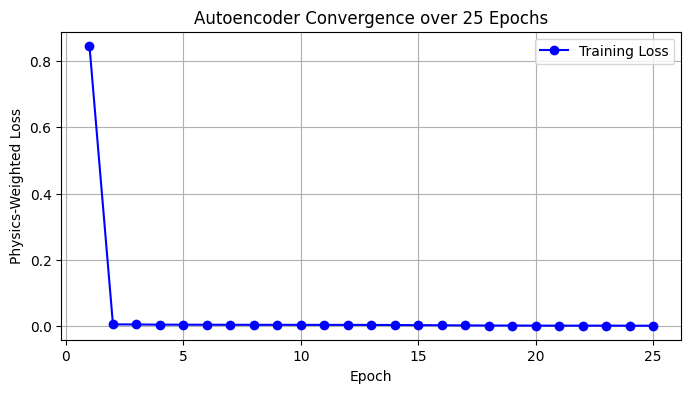

In [18]:
import matplotlib.pyplot as plt
import torch.optim as optim
import torch

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. HARD RESET: Give the model a fresh brain
model = JetAutoencoder().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 25
train_losses = []

print(f"Starting intensive training for {num_epochs} epochs...")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for batch_idx, batch in enumerate(ram_train_loader):
        # Handle the TensorDataset tuple
        images = batch[0].to(device)

        optimizer.zero_grad()
        reconstructed = model(images)
        loss = physics_weighted_mse(reconstructed, images)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(ram_train_loader)
    train_losses.append(epoch_loss)

    # Print every 5 epochs to keep the output clean
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {epoch_loss:.2f}")

print("Training finished!")

# Plot the Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o', color='b', label='Training Loss')
plt.title('Autoencoder Convergence over 25 Epochs')
plt.xlabel('Epoch')
plt.ylabel('Physics-Weighted Loss')
plt.grid(True)
plt.legend()
plt.show()

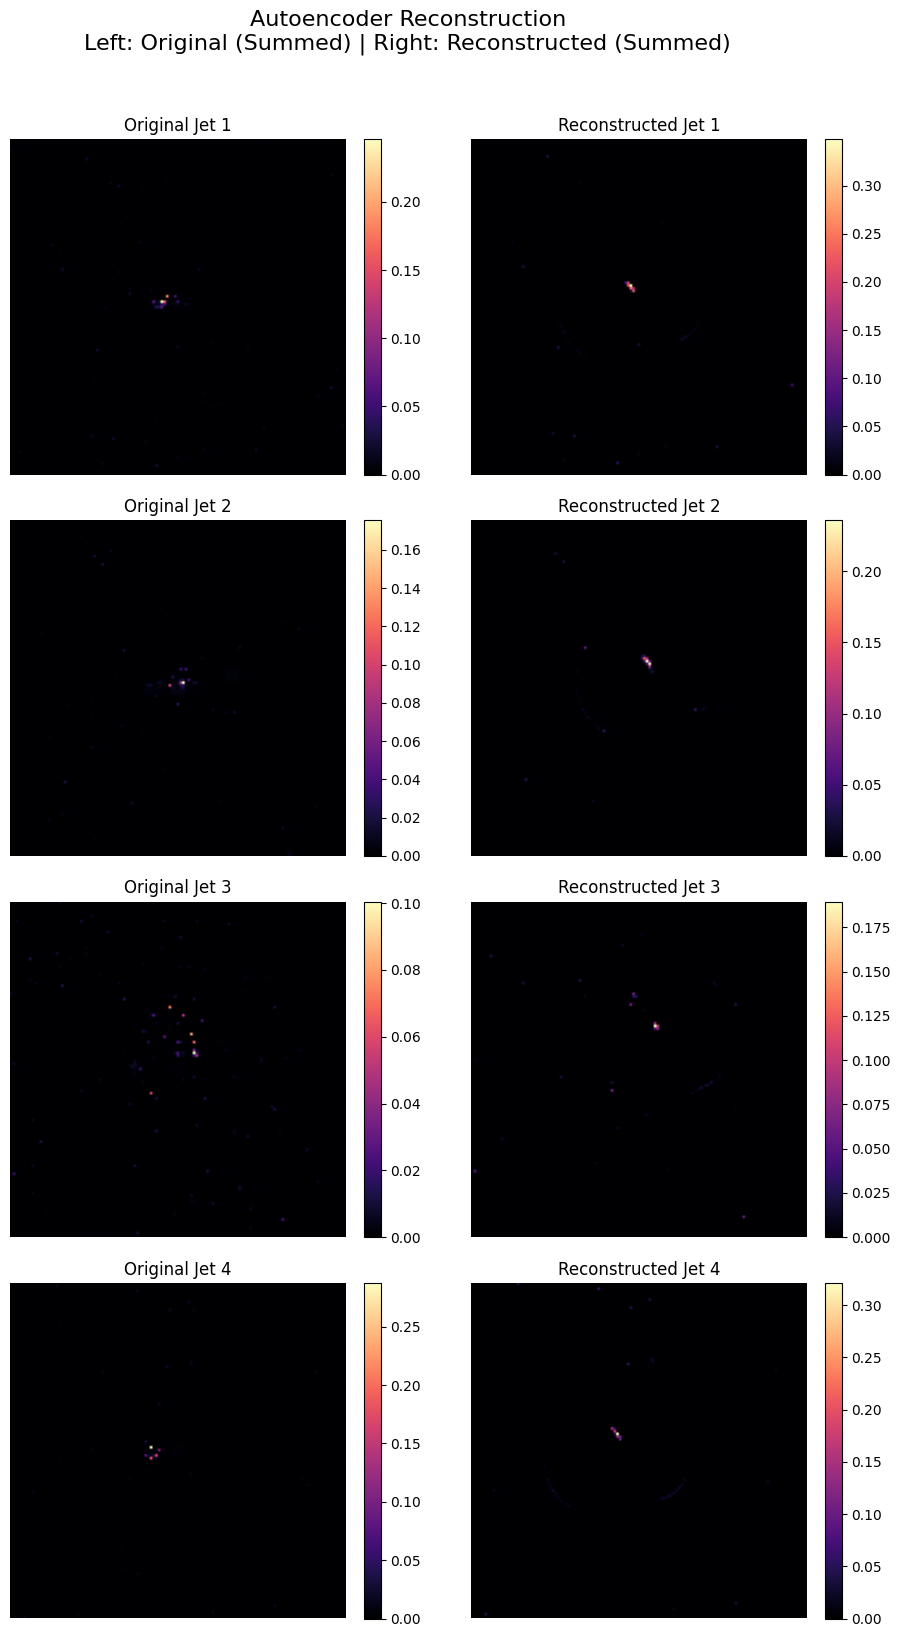

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_reconstruction_ram(model, dataloader, device, num_jets=4):
    model.eval() # Set to evaluation mode

    # Grab one batch of data
    dataiter = iter(dataloader)
    batch = next(dataiter)

    # THE FIX: Unpack the tuple generated by TensorDataset
    if isinstance(batch, list) or isinstance(batch, tuple):
        images = batch[0]
    else:
        images = batch

    images = images.to(device)

    with torch.no_grad():
        reconstructed = model(images)

    # Move back to CPU for matplotlib
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    fig, axes = plt.subplots(num_jets, 2, figsize=(10, 4 * num_jets))
    fig.suptitle("Autoencoder Reconstruction\nLeft: Original (Summed) | Right: Reconstructed (Summed)", fontsize=16, y=1.02)

    for i in range(num_jets):
        # Sum across the 3 channels to show the total energy structure
        orig_sum = np.sum(images[i], axis=0)
        recon_sum = np.sum(reconstructed[i], axis=0)

        # Plot Original
        ax1 = axes[i, 0]
        im1 = ax1.imshow(orig_sum, cmap='magma', origin='lower')
        ax1.set_title(f"Original Jet {i+1}")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.axis('off')

        # Plot Reconstructed
        ax2 = axes[i, 1]
        im2 = ax2.imshow(recon_sum, cmap='magma', origin='lower')
        ax2.set_title(f"Reconstructed Jet {i+1}")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization!
visualize_reconstruction_ram(model, ram_train_loader, device, num_jets=4)

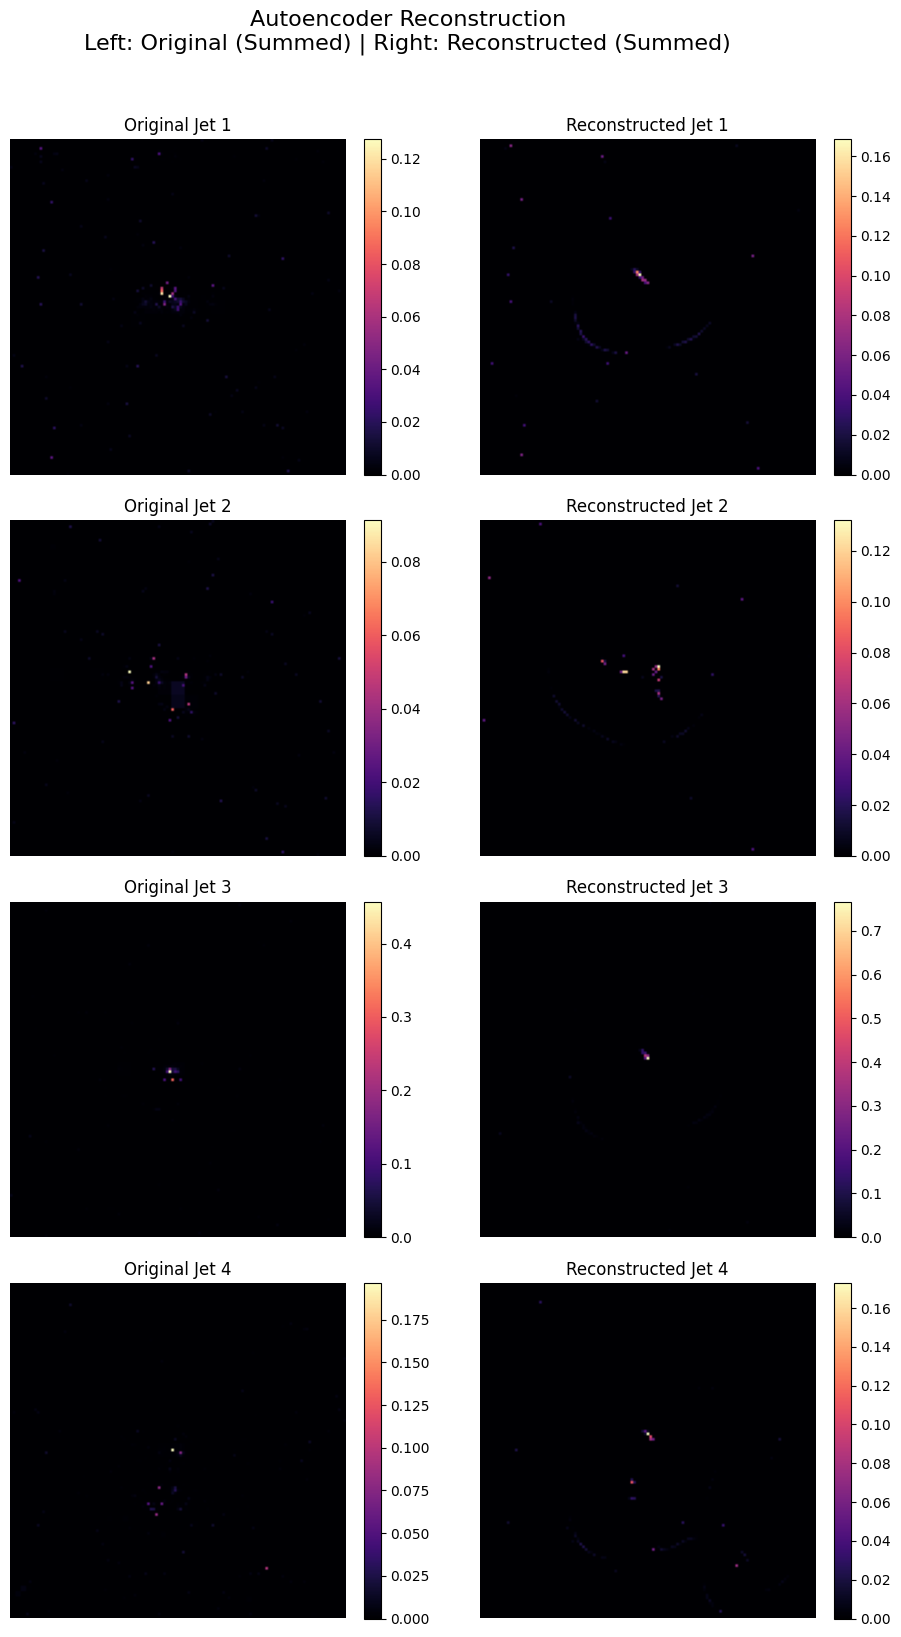

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_reconstruction_ram(model, dataloader, device, num_jets=4):
    model.eval() # Set to evaluation mode

    # Grab one batch of data
    dataiter = iter(dataloader)
    batch = next(dataiter)

    # THE FIX: Unpack the tuple generated by TensorDataset
    if isinstance(batch, list) or isinstance(batch, tuple):
        images = batch[0]
    else:
        images = batch

    images = images.to(device)

    with torch.no_grad():
        reconstructed = model(images)

    # Move back to CPU for matplotlib
    images = images.cpu().numpy()
    reconstructed = reconstructed.cpu().numpy()

    fig, axes = plt.subplots(num_jets, 2, figsize=(10, 4 * num_jets))
    fig.suptitle("Autoencoder Reconstruction\nLeft: Original (Summed) | Right: Reconstructed (Summed)", fontsize=16, y=1.02)

    for i in range(num_jets):
        # Sum across the 3 channels to show the total energy structure
        orig_sum = np.sum(images[i], axis=0)
        recon_sum = np.sum(reconstructed[i], axis=0)

        # Plot Original
        ax1 = axes[i, 0]
        im1 = ax1.imshow(orig_sum, cmap='magma', origin='lower')
        ax1.set_title(f"Original Jet {i+1}")
        plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
        ax1.axis('off')

        # Plot Reconstructed
        ax2 = axes[i, 1]
        im2 = ax2.imshow(recon_sum, cmap='magma', origin='lower')
        ax2.set_title(f"Reconstructed Jet {i+1}")
        plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
        ax2.axis('off')

    plt.tight_layout()
    plt.show()

# Run the visualization!
visualize_reconstruction_ram(model, ram_train_loader, device, num_jets=4)

In [26]:
model.eval()
all_mse = []
all_rel_energy_error = []

with torch.no_grad():
    for batch in ram_train_loader:
        if isinstance(batch, (list, tuple)):
            images = batch[0]
        else:
            images = batch
        images = images.to(device)
        reconstructed = model(images)

        # Per-channel MSE
        mse = torch.mean((reconstructed - images)**2, dim=[0,2,3])
        all_mse.append(mse.cpu())

        # Relative energy error
        pred_e = reconstructed.sum(dim=[2,3])
        true_e = images.sum(dim=[2,3])
        rel_err = torch.abs(pred_e - true_e) / (true_e + 1e-8)
        all_rel_energy_error.append(rel_err.cpu())

all_mse = torch.stack(all_mse).mean(dim=0)
all_rel_energy_error = torch.cat(all_rel_energy_error).mean()

print(f"Test Set Results:")
print(f"ECAL   MSE: {all_mse[0]:.6f}")
print(f"HCAL   MSE: {all_mse[1]:.6f}")
print(f"Tracks MSE: {all_mse[2]:.6f}")
print(f"Mean Relative Energy Error: {all_rel_energy_error:.4f}")

Test Set Results:
ECAL   MSE: 0.000010
HCAL   MSE: 0.000013
Tracks MSE: 0.000002
Mean Relative Energy Error: 0.2695
